# Title: Improving detection of fake news using dataset augmentation by generating more fake articles using LLM and using RL q-learning to determine optimal amount of data augmentation.

#### Members' Names or Individual's Name: Alexander Eliseev , Divya Bharathi Kannappan , Ahmed Mohamed
####  Emails: aeliseev@torontomu.ca, divya.kannappan@torontomu.ca (add your emails)

# Introduction:

#### Problem Description:

The unchecked spread of misinformation across digital platforms has evolved into a systemic threat, making the detection of "fake news" one of the most pressing challenges for modern information systems. While machine learning offers a promising defense, these models are only as effective as the data used to train them. Currently, we face a significant bottleneck: the lack of balanced, high-fidelity datasets required to build truly resilient detection systems.

#### Context of the Problem:

In practice, the data we encounter is rarely symmetrical. Real-world datasets suffer from a severe class imbalance, where legitimate news articles far outnumber verified instances of misinformation. This scarcity prevents models from learning the nuanced features of deceptive content, leading to a "blind spot" where the system generalizes poorly to new, emerging threats. Furthermore, because misinformation is constantly evolving in style and structure, models trained on static, limited data quickly become obsolete. The biggest problem remains is being able to identify real misinformation and fake news published by verified sources. Unverified sources can be simply assumed to be predominantly fake and simply black listed but, it is misinformation created by long standing and verified sources which remains the problem and needs to be kept in check. Luckily most articles published by verified sources are going to be curated or peer reviewed multiple times and as such the number of fake information articles will nautrally be far lower than of real ones. Classification training however wants all classes to be in equal amounts for the best performance as such the limiting factor will be the number of fake news in the training pool. Since no more real fake news are available online the remaining solution is to augment the available ones with more artificially generated ones. In this project this will be achieved using NLP.
#### Limitation About other Approaches:

Traditional detection frameworks typically fall short in two key areas:

Static Data Dependency: Most approaches rely strictly on pre-existing labeled datasets, failing to account for the inherent scarcity of fake news samples.

Lack of Generative Innovation: There is a notable absence of generative modeling to bridge the data gap. By failing to synthesize diverse training examples, existing models are prone to overfitting—they become excellent at identifying past fake news but fail to recognize the misinformation of tomorrow.

#### Solution:

The proposed method addresses the problem of limited and imbalanced fake news data by generating high-quality synthetic fake articles using LLMs guided by extracted topics and named entities. This augmented dataset improves the model’s ability to learn diverse fake news patterns, leading to better classification performance and generalization. Furthermore the augmented dataset allows for a greater ceiling of real news articles to be used in training without causing a bias in the model.


# Background

| Reference            | Explanation                                                | Dataset/Input       | Weakness                            |
| -------------------- | ---------------------------------------------------------- | ------------------- | ----------------------------------- |
| BERT (Devlin et al.) | Transformer-based model for text classification            | Large-scale corpora | High computational cost             |
| LSTM Networks        | Sequence-based deep learning model for text classification | Text datasets       | Poor long-range dependency handling |
| LDA (Blei et al.)    | Topic modeling using bag-of-words                          | Text corpus         | Ignores semantic meaning            |
| NER (spaCy)          | Extracts named entities such as people                     | Raw text            | May introduce noise                 |
| LLMs (LLAMA 3)       | Generates human-like text based on prompts                 | Prompt-based input  | Risk of synthetic bias              |


# Methodology

This project proposes a data augmentation-based approach for imporving fake news detection by combining topic modeling, named entity recognition (NER), large language models (LLMs), and reinforcement learning. Fake news articles are first scrapped off the internet and then processed using spaCy NER to extract named entities from the articles. These named entities are then removed from the texts along with generic words, punctuation and other noise to avoid them getting identified as topics. After which the remaining words of each article are lemmatized and kept as tokens. Finally LDA topic modelling is performed on the tokenized set of the fake articles to extract topics from them. Due to the variety of fake news and a considerable training pool of 1835 articles a total of 200 different topics could be reliably extracted. Finally, the named entities and topics are randomly selected and used as prompts for an LLM to generate a news article involving them. In this project LLAMA 3 is used.

With the data augmentation complete, an LSTM classifier is trained to classsify fake/real news and to set a baseline it is trained using only available fake and real news with the real news far outnumbering the fake ones. To improve the accuracy of the model by balancing the training data,the fake news are augmented with their artifically generated counterparts.

Lastly RL is used to determine the optimal amount of data augmentation should be done for the maximum possible accuracy from the classifier. Too much augmentation can result in bias towards the generated fake news articles and too little of them would not have an affect on the accuracy.

# Implementation

### Step 1: Data Collection

Fake and real news articles are collected using the GossipCop dataset which has thousands of links to fake and real articles posted from various new sources on the internet. This was one only English lanugage dataset of fake and real news used in the original research paper. Python scripts are used to read the article URLs from the GossipCop dataset and then use the native Newspaper library in Python to scrape the article text from the internet. 

* Real news articles are downloaded and saved into a training directory
* Fake news articles are similarly collected and stored into a training folder
* 400 Fake and 400 Real articles are stored seperately in a testing directory
* Articles with insufficient content are filtered out, articles that have been taken down are also ignored. Roughly 40% of the GossipCop dataset is no longer valid and can't be retrieved.

---

### Step 2: Data Preprocessing

The collected fake news articles undergo preprocessing, including:

* Lowercasing text
* Removing punctuation and stopwords
* Lemmatization using NLTK
* Tokenization of words
* Named Entity Recognition (NER) using spaCy is applied to extract names of people from the articles.

*Note above preprocessing operations are done as needed directly things like classifier training or LDA for prompt engineering for generating new fake articles using LLAMA 3 and so on. The original downloaded article texts remain untouched in the training folders besides having things like <br > removed.

---

### Step 3: Topic Extraction using LDA

Latent Dirichlet Allocation (LDA) is applied to the cleaned fake news dataset to identify underlying topics. These topics represent common themes present in fake news articles and is used for prompt topics to feed into LLAMA 3 LLM to generate more fake news articles.

* Articles are converted into bag-of-words format
    * After NER is used to remove all named entities, lower casing text, removing stopwords/noise and Lemmatizing words
* LDA model is trained to extract multiple topics
* Each topic consists of a set of representative words that relate to one another
* Total of 200 different topics could be extracted whilst maintaining their quality and them not being too generic

---

### Step 4: Synthetic Fake News Generation

To address class imbalance, synthetic fake news articles are generated using a Large Language Model (LLAMA 3).

* Random combinations of extracted topics and named people are selected
* These are used as prompts to guide the LLM
* The model generates realistic fake news articles based on the prompts
* Generated articles are filtered to ensure quality before being saved, removing extra text that the LLM may have generated by accident

Example prompt given to LLAMA 3:
    You are a news article generator. 

    Write an article given the following people:
    ['Neil Sean', 'Magda', "Katy Perry's", 'Maria Menounos', 'Guy P. Jones']

    And make up a logical story or argument or drama or event involving the listed people and these topic words:
    ['think', 'last', 'lexus', 'crash', "'re", 'former', 'episode', 'highway', 'paparazzo','moment']


    Write 3-5 Paragraphs using the topic words and the people in a logical manner. Try to avoid repeats.
    You may choose to make it in gossip news style or make it more formal rumours. Or a formal event that you are reporting on.
    It may also be an anouncement or just news.

    Make it anywhere between 600-1200 words.

    Commit to the chosen style.

Setting up the fake news generation took a fair bit of trial and error. As a whole, it is very resource heavy especially if going for a high degree of quality. The inital setup used was the prompt above where the model was given freedom to choose the style at random on its own and given a token limit of 1500. The first batch of articles were generated overnight, ~14 hours worth of time and a mere 43 were made. They are numberered 0-42.txt and can be viewed in the Data/train/GeneratedFake folder. This initial batch was upon inspection, of very believable quality and good variety and would probably be the best for training quality however. The rate at which they were being made was just too slow. The generation setup would push the hardware setup to use 32/32GB of RAM and the RTX 4060 GPU to 100% utilization. And even still it was like 1 article every 20 minutes. Taking into account that there are 1800 real fakes and ~6000 real articles in the training set that can be used. 80 articles/day is just not practical. To improve the rate of generating the fake articles, max new tokens was reduced down to 600, and number of returns was upped to 3, 10 was also tested. So with the LLM the biggest time sink in generation is inferencing the prompt to capture the context of what should be generated. Once the context is setup, the generation of the text itself is relatively fast. Based on observation, it takes about the same amount of time to write 10 slightly different articles from the same prompt as it does to generate 2 articles from 2 different prompts, assuming same token size for the articles. With this said, the prompt was simplified to reduce decision making for the LLM and also token limit was reduced to 600. And about 3 similar articles would now be trained for every prompt. This would reduce their overall quality as training data as there is less difference between the articles and the articles themselves may have less diverse vocabulary but this decrease in quality would be offset by the fact that the bias in the training dataset would be reduced as more fake news articles were present and more real articles could be used in training too. Either way after the changes, about 4-5x as many could be made in the same amount of time. Tragically on the 2nd night of generation the computer crashed, either from the utilization or possibly because of the power flickering from the thunderstorm outside so rather than having 300 the next morning only 75 more were made thoughout the night. Either way a lot better rate.



---

### Step 5: Classification Model

A Long Short-Term Memory (LSTM) and BERT transformer models are used to classify news articles as real or fake.

* Input: Batches of real fake, syntehtic fake and real news articles
* Output: Binary classification (real/fake)
* The models learn linguistic patterns and contextual cues

LSTM is a lot lighter than transformers in terms of memory which is why it was considered being used over using BERT + Transformer setup. And even it required batch loading and would crash and run out of memory on a 32GB setup if the entire dataset of only ~10k articles would be loaded. To avoid the memory issues batching implemented which solved the problem and allowed it to train. Inital results were good, with the original training set of ~1800 fakes and ~6k real articles resulting in a final model that would have a ~52% accuracy. 

Upon being given time to revise the project, the BERT + transformer model from the original research paper was also implemented and subsequently tested. It as expected was a lot heavier and much more computationally heavy to run. But, it did perform a lot better at the classification task.

---

### Step 6: Reinforcement Learning Optimization

Reinforcement learning is used to determine the optimal number of synthetic fake news samples to include in training.

* Action: Number of synthetic samples added
* Reward: Validation accuracy of the classifier
* Goal: Maximize classification performance

Reinforcement learning and using Q-learning was the proposed solution in the reasearch paper. It is certainly a novel idea as this is something that could probably be implemented simply using a regression model on a dataset of accuracy vs number of synthetic fake articles used in training. Which when plotted would probably look like a quadratic function as accuracy would initially increase benefitting from the synthetics and then start to decrease once more as they become a bias in and of themselves outweighing in value the actual real fakes and overfitting the model. But, using Q-learning to converge by adding or taking away X aritifical articles every step from the training pool and seeing the accuracy from the adjustment certainly works too. Not sure how effecient it is resource wise not to mention that it would have limited exploration and could get stuck but, it could be more efficient if it converges to the global maxima right away. It was tested by having both the BERT and LSTM models run many times over with changing amounts of generated articles being used in the training pool. And using their final accuracy score after that training pool distrbution to determine if more or less generated articles should be used. This process was repeated until Q-learning converged unto the optimal amount of generated articles that should be used in training.

---

### Key Idea

The key idea of this project is to improve fake news detection by augmenting the dataset with high-quality synthetic data generated using LLMs, rather than relying solely on limited real-world data. Below, is the final demo of the implementation described above. The demo consists of 3 parts, first testing the classifiers with no data augmentation, then with all available augmented data included and lastly a run of RL to compute the optimal amount of data augmentation that should be used. Then the experiment is repeated but with a smaller initial training dataset of real and fake articles from the internet. Comments below explain the rationale behind each part of the experiment further.


# Paper Architecture
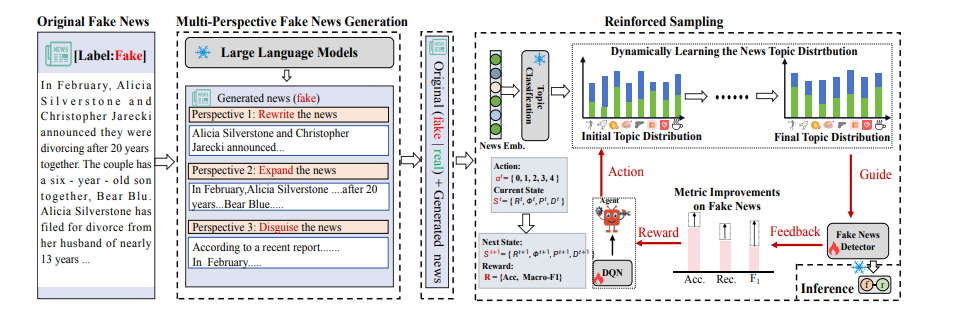

# OUR IMPLEMENTATION
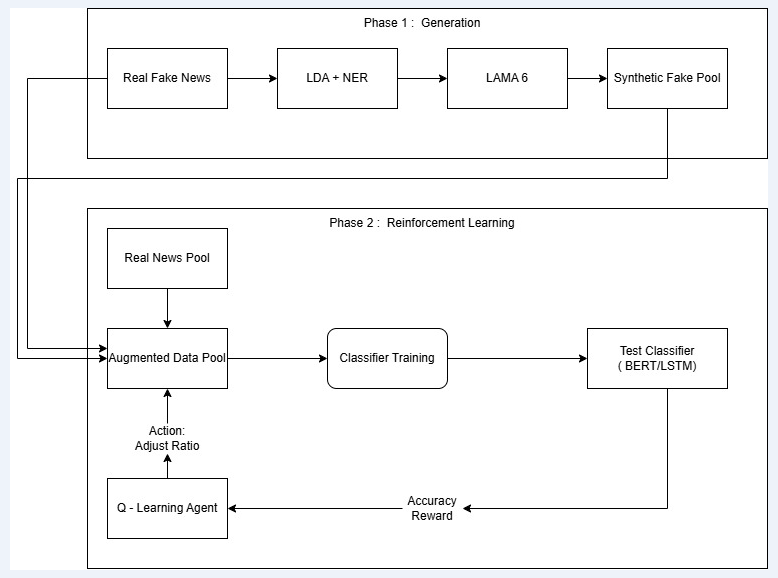


# Comparison of code implementation between original paper and the replication project:

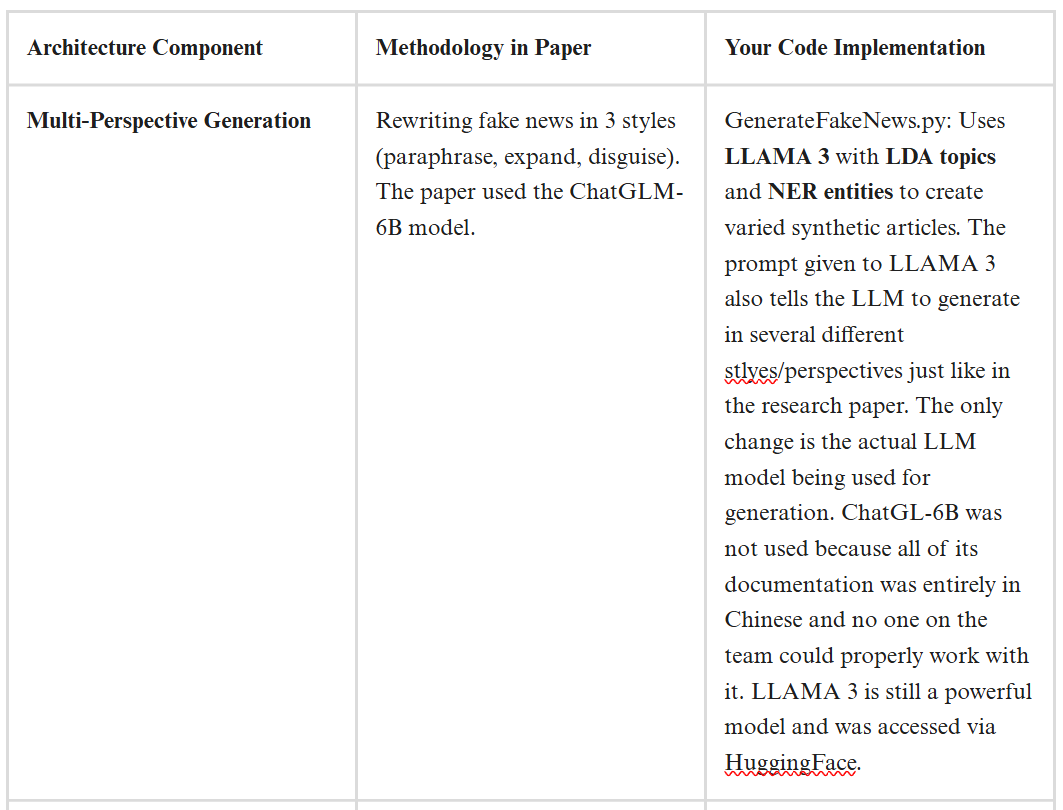
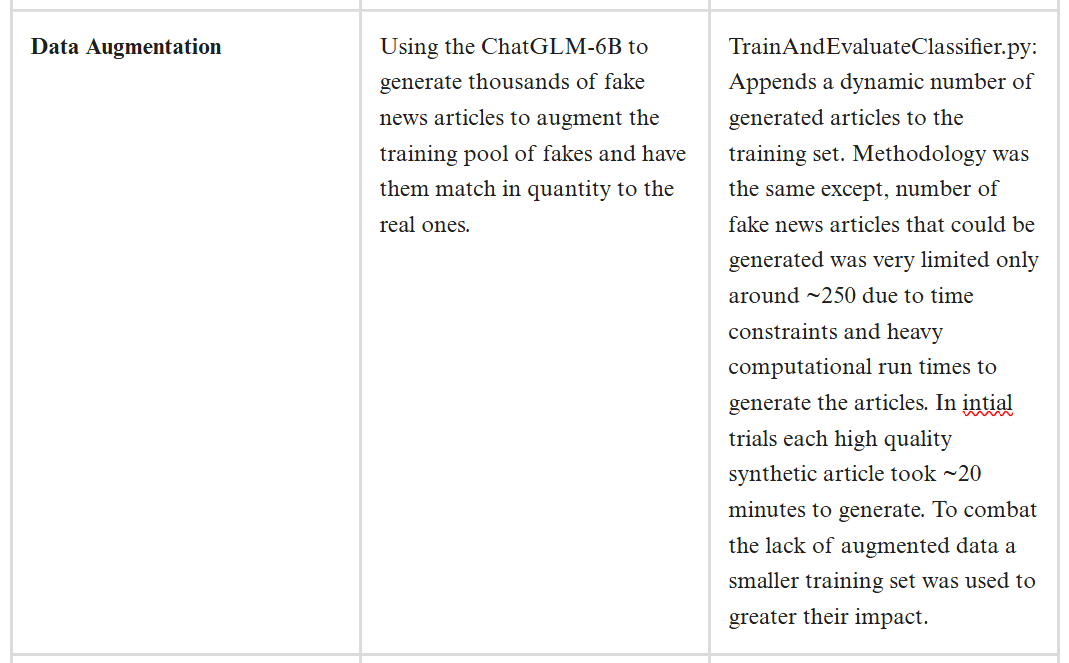
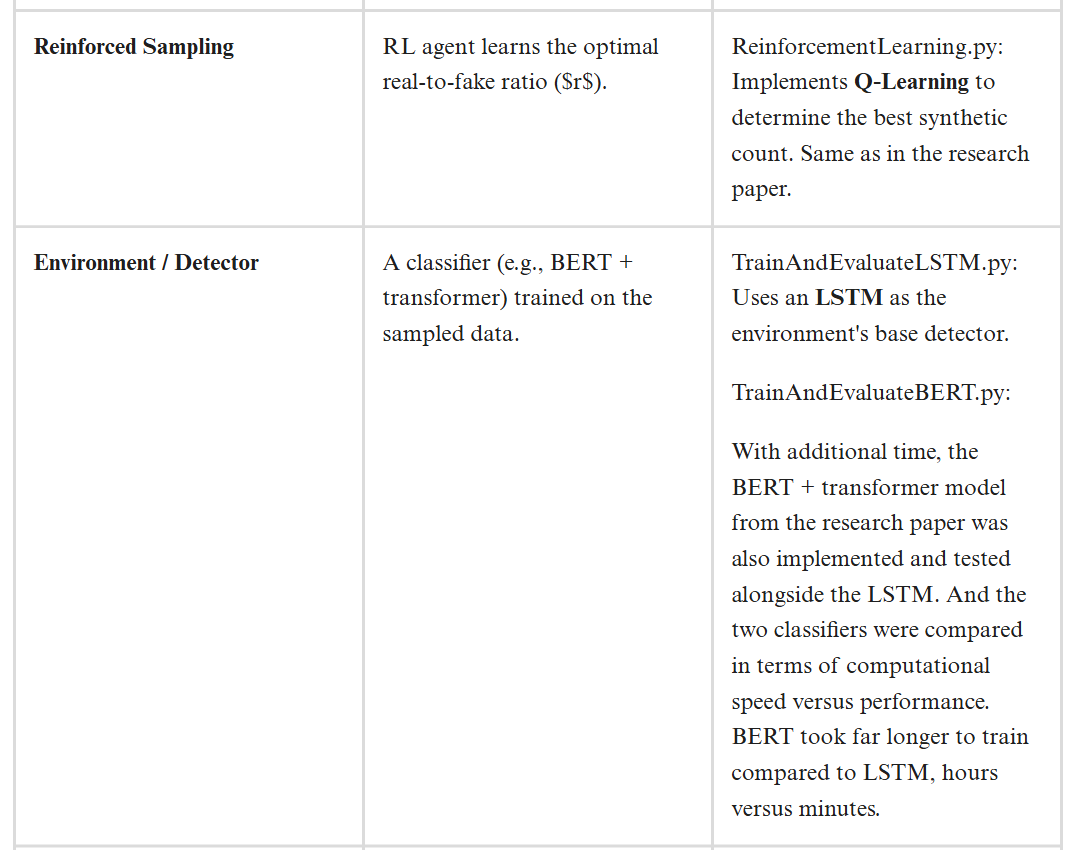  
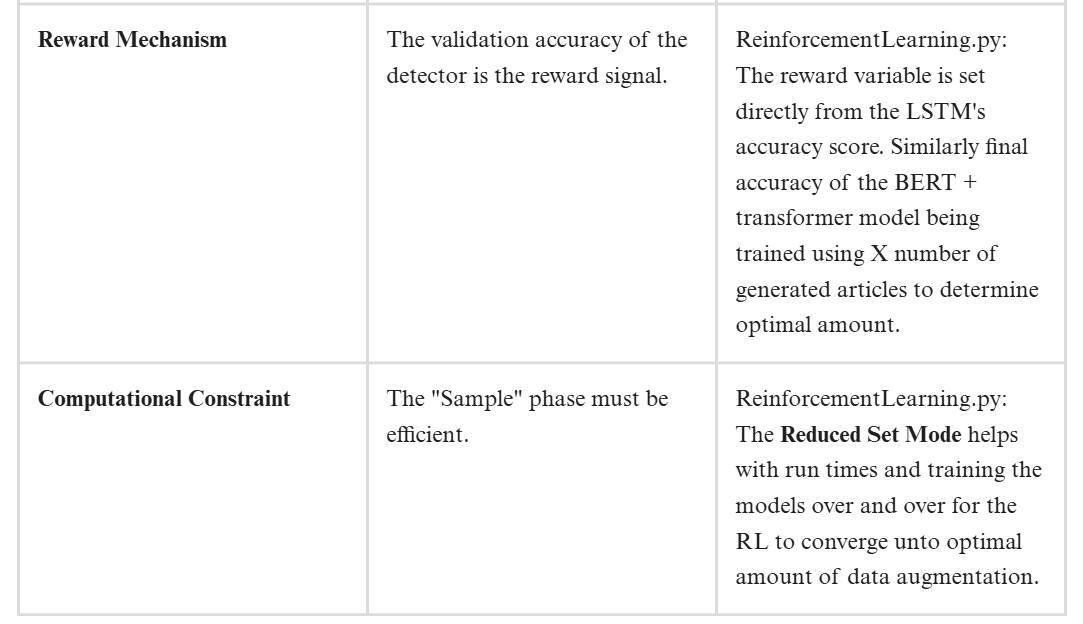  


As shown above, the replication project follows the GSFND framework implementation of the research paper as closely as possible. (Tong et al., 2025). The methodology is split into two distinct phases to handle the 'Cold Start' problem of fake news detection:

### Phase 1 (The 'Generate' Phase): 
We address the lack of high-fidelity fake news data by using LLAMA 3. To ensure the generated news maintains the 'DNA' of real-world misinformation, we use LDA Topic Modeling and Named Entity Recognition (NER) to extract context, which is then fed into the LLM as a randomized prompt seed for LLAMA to generate fake news about different topics that are the same as in the real fakes.

### Phase 2 (The 'Sample' Phase): 
Simply adding more data can introduce noise and adding too many generated fakes can cause the model to start overfitting to them. We implemented a Reinforcement Learning (Q-Learning) agent that acts as a 'gatekeeper.' It adjusts the ratio of synthetic data based on the performance of the LSTM and BERT classifiers. By receiving the accuracy as a 'Reward,' the agent identifies the 'Goldilocks' amount of synthetic data that maximizes classification performance of the models without over-fitting to the synthetic data. 

In [1]:
#First code cell runs the LSTM classifier using no generated fake articles but, using all 1835 real fake articles and ~6000 real articles from the internet.
#This sets a baseline accuracy of what is to be expected from the classifier if only available data is used. Averaging accuracy from 10 runs 
#to account for variance.
import sys
import importlib
sys.path.append("src")
import TrainAndEvaluateClassifier
import TrainAndEvaluateLSTM
import ReinforcementLearning
import TrainAndEvaluateBERT
importlib.reload(TrainAndEvaluateClassifier)
importlib.reload(TrainAndEvaluateLSTM)
importlib.reload(ReinforcementLearning)
importlib.reload(TrainAndEvaluateBERT)
from TrainAndEvaluateClassifier import TrainAndEvaluateClassifer
from TrainAndEvaluateLSTM import TrainAndEvaluateLSTM
from ReinforcementLearning import train_q_learning
from ReinforcementLearning import train_q_learning_reduced_set
from TrainAndEvaluateBERT import TrainAndEvaluateBERT

def run_single_experiment(): #Function also available in main.py
    print("=== Running LSTM Classifier, Training using all fake and real articles available. No generated fake articles are used. ===")

    data = TrainAndEvaluateClassifer(
        NumberOfArtificialArticlesTouse=0,
        UseAll=1
    )

    accuracy = TrainAndEvaluateLSTM(data)
    print(f"\nBaseline accuracy: {accuracy:.4f}")

    return accuracy

AverageAccuracy = 0

for i in range(10):
    AverageAccuracy += run_single_experiment()

AverageAccuracy = AverageAccuracy/10

print(f"\nAverage baseline accuracy: {AverageAccuracy:.4f}")

=== Running LSTM Classifier, Training using all fake and real articles available. No generated fake articles are used. ===


KeyboardInterrupt: 

In [ ]:
#As can be seen in the cell above, the LSTM model struggles to classify real from fakes only achieving an average accuracy of ~53% when trained using 
#just the original fake and real news articles collected online. Next this cell will show what happens when all of the generated fake news articles are
#added into the training pool.
def run_single_experiment(): #Function also available in main.py
    print("=== Running LSTM Classifier, Training using all fake and real articles available. No generated fake articles are used. ===")

    data = TrainAndEvaluateClassifer(
        NumberOfArtificialArticlesTouse=100000, #Any number that exceeds their max will just cause all to be used.
        UseAll=1
    )

    accuracy = TrainAndEvaluateLSTM(data)
    print(f"\nAccuracy using all available source and augmented data: {accuracy:.4f}")

    return accuracy

AverageAccuracy = 0

for i in range(10):
    AverageAccuracy += run_single_experiment()

AverageAccuracy = AverageAccuracy/10

print(f"\nAverage accuracy using all available source and augmented data: {AverageAccuracy:.4f}")

run_single_experiment()

=== Running LSTM Classifier, Training using all fake and real articles available. No generated fake articles are used. ===
Train size: 8547
Test size: 800
Epoch 1, Loss: 38.1909
Epoch 2, Loss: 35.4146
Epoch 3, Loss: 33.2224
Epoch 4, Loss: 29.1794
Epoch 5, Loss: 25.0197
Test Accuracy: 0.5500

Accuracy using all available source and augmented data: 0.5500
=== Running LSTM Classifier, Training using all fake and real articles available. No generated fake articles are used. ===
Train size: 8547
Test size: 800
Epoch 1, Loss: 38.3354
Epoch 2, Loss: 35.9636
Epoch 3, Loss: 33.6233
Epoch 4, Loss: 29.3208
Epoch 5, Loss: 24.5994
Test Accuracy: 0.5450

Accuracy using all available source and augmented data: 0.5450
=== Running LSTM Classifier, Training using all fake and real articles available. No generated fake articles are used. ===
Train size: 8547
Test size: 800
Epoch 1, Loss: 38.0849
Epoch 2, Loss: 35.6113
Epoch 3, Loss: 33.3667
Epoch 4, Loss: 29.1892
Epoch 5, Loss: 24.2081
Test Accuracy: 0.5

0.545

In [ ]:
#As we can see above, the accuracy of the model has marginally imrpoved by <1% at most 1% but is basically the same. Which makes sense considering that only about ~250 generated articles are
#actually used to augment the fake news articles portion of the training data set. This means that final difference between the number
#of fake and real articles is still massive isntead of it being 1835 vs ~6k now its 2050 vs ~6k.  Real imrpovements at this scale will only be seen once
#substaintially more generated articles are added into the training pool. This cell tr
def run_rl_optimization():
    print("\n=== Running Q-Learning Optimization Using All Available Real, Generated Fake and Fake articles for classifer training. ===")

    best = train_q_learning()

    print(f"\nOptimal number of synthetic articles: {best}")

run_rl_optimization()


=== Running Q-Learning Optimization Using All Available Real, Generated Fake and Fake articles for classifer training. ===

=== Episode 1 ===
Train size: 8430
Test size: 800
Epoch 1, Loss: 37.7256
Epoch 2, Loss: 34.9211
Epoch 3, Loss: 33.3548
Epoch 4, Loss: 30.5600
Epoch 5, Loss: 27.4309
Test Accuracy: 0.5288
State: 150, Action: -20, Reward: 0.5288
Train size: 8410
Test size: 800
Epoch 1, Loss: 36.6553
Epoch 2, Loss: 34.4886
Epoch 3, Loss: 32.4648
Epoch 4, Loss: 28.6323
Epoch 5, Loss: 24.5351
Test Accuracy: 0.5537
State: 130, Action: -20, Reward: 0.5537
Train size: 8390
Test size: 800
Epoch 1, Loss: 36.7216
Epoch 2, Loss: 34.4670
Epoch 3, Loss: 32.5460
Epoch 4, Loss: 29.1315
Epoch 5, Loss: 24.6756
Test Accuracy: 0.5288
State: 110, Action: -20, Reward: 0.5288
Train size: 8370
Test size: 800
Epoch 1, Loss: 36.9595
Epoch 2, Loss: 34.2570
Epoch 3, Loss: 32.5473
Epoch 4, Loss: 29.1827
Epoch 5, Loss: 24.7485
Test Accuracy: 0.5337
State: 90, Action: -20, Reward: 0.5337
Train size: 8350
Test 

In [ ]:
#As can be seen above, the final Q-learning calculates that the best number of generated articles to use is 0. The Q-learning struggles as the local changes are very 
#minor and because the overall imrpvoement on average is a mere ~1% or even less. Q-learning treats it as noise and sees no overall imrpovement.
#Unfortunately due to a lack of time, more generated articles of good quality are simply not avaialable and as such to better demonstrate the 
#positve affect of augmenting the traning data that is lacking in quanity, a reduced training dataset is used on the same 3 cells above.
#But this time there are only 400 real fake articles and 800 real articles to start.
def run_single_experiment(): #Function also available in main.py
    print("=== Running LSTM Classifier, Training using all fake and real articles available. No generated fake articles are used. ===")

    data = TrainAndEvaluateClassifer(
        NumberOfArtificialArticlesTouse=0,
        UseAll=0, #Telling the classifier to only extract 400 and 800 random fake/real articles from the training pool.
        NumberOfRealFakeArticles=400,
        NumberOfRealArticles=800
    )

    accuracy = TrainAndEvaluateLSTM(data)
    print(f"\nBaseline accuracy: {accuracy:.4f}")

    return accuracy

AverageAccuracy = 0

for i in range(25):
    AverageAccuracy += run_single_experiment()

AverageAccuracy = AverageAccuracy/25

print(f"\nAverage baseline accuracy using reduced dataset set of 400/1200 articles: {AverageAccuracy:.4f}")

=== Running LSTM Classifier, Training using all fake and real articles available. No generated fake articles are used. ===
Train size: 1200
Test size: 800
Epoch 1, Loss: 6.7764
Epoch 2, Loss: 6.3460
Epoch 3, Loss: 6.0577
Epoch 4, Loss: 5.8287
Epoch 5, Loss: 5.6026
Epoch 6, Loss: 5.3000
Epoch 7, Loss: 4.7795
Epoch 8, Loss: 4.2392
Epoch 9, Loss: 3.6998
Epoch 10, Loss: 3.2307
Epoch 11, Loss: 2.8264
Epoch 12, Loss: 2.5779
Epoch 13, Loss: 2.4216
Epoch 14, Loss: 2.3700
Epoch 15, Loss: 2.3217
Test Accuracy: 0.4963

Baseline accuracy: 0.4963
=== Running LSTM Classifier, Training using all fake and real articles available. No generated fake articles are used. ===
Train size: 1200
Test size: 800
Epoch 1, Loss: 6.8727
Epoch 2, Loss: 6.1647
Epoch 3, Loss: 5.9200
Epoch 4, Loss: 5.6734
Epoch 5, Loss: 5.4033
Epoch 6, Loss: 4.9876
Epoch 7, Loss: 4.6003
Epoch 8, Loss: 4.3218
Epoch 9, Loss: 4.2134
Epoch 10, Loss: 3.7326
Epoch 11, Loss: 3.2850
Epoch 12, Loss: 3.0140
Epoch 13, Loss: 2.8140
Epoch 14, Loss:

In [ ]:
#As can be seen above, after reducing the training size to 400/800 articles respectively the overall accuracy on average has gone down by about ~5%
#down to ~50% from the 55% when the entire dataset was avaialble before. This makese sense as the model is being trained with less data. Now
#the ~250 available LLM generated fake articles will be used to augment the smaller training dataset bringing it to ~650 fakes and 800 real articles.
#Here the augmented articles bridge the gap between the number of fake and real articles in the training pool substantially more and this should 
#have a more noticeable affect on the training and performance of the model as a result.
def run_single_experiment(): #Function also available in main.py
    print("=== Running LSTM Classifier, Training using all fake and real articles available. No generated fake articles are used. ===")

    data = TrainAndEvaluateClassifer(
        NumberOfArtificialArticlesTouse=10000,
        UseAll=0, #Telling the classifier to only extract 400 and 800 random fake/real articles from the training pool.
        NumberOfRealFakeArticles=400,
        NumberOfRealArticles=800
    )

    accuracy = TrainAndEvaluateLSTM(data)
    print(f"\nBaseline accuracy: {accuracy:.4f}")

    return accuracy

AverageAccuracy = 0

for i in range(25):
    AverageAccuracy += run_single_experiment()

AverageAccuracy = AverageAccuracy/25

print(f"\nAverage accuracy using smaller training dataset and all available generated fake articles for augmentation: {AverageAccuracy:.4f}")

=== Running LSTM Classifier, Training using all fake and real articles available. No generated fake articles are used. ===
Train size: 1447
Test size: 800
Epoch 1, Loss: 8.2863
Epoch 2, Loss: 7.8880
Epoch 3, Loss: 7.4233
Epoch 4, Loss: 7.1088
Epoch 5, Loss: 6.3536
Epoch 6, Loss: 5.9407
Epoch 7, Loss: 5.0278
Epoch 8, Loss: 4.8055
Epoch 9, Loss: 4.5077
Epoch 10, Loss: 3.7347
Epoch 11, Loss: 3.0893
Epoch 12, Loss: 2.8214
Epoch 13, Loss: 2.4993
Epoch 14, Loss: 3.5770
Epoch 15, Loss: 2.8167
Test Accuracy: 0.5212

Baseline accuracy: 0.5212
=== Running LSTM Classifier, Training using all fake and real articles available. No generated fake articles are used. ===
Train size: 1447
Test size: 800
Epoch 1, Loss: 8.2216
Epoch 2, Loss: 7.7684
Epoch 3, Loss: 7.2562
Epoch 4, Loss: 6.7160
Epoch 5, Loss: 6.4415
Epoch 6, Loss: 5.6434
Epoch 7, Loss: 5.2957
Epoch 8, Loss: 4.8530
Epoch 9, Loss: 4.2020
Epoch 10, Loss: 3.7429
Epoch 11, Loss: 3.2696
Epoch 12, Loss: 2.8903
Epoch 13, Loss: 2.7109
Epoch 14, Loss:

In [ ]:
#As can be seen above, adding the ~250 fake articles and increasing the number of fake articles from 400 -> 650 and bringing them a lot closer
#in count to the 800 real articles. Has resulting the accuracy improving on average by about ~1%. Which compared to before when the accuracy 
#was basically unaffected due to how little were added. Taking into account the limited number of high quality and truly unique fake articles generated, 
#considering that to increase their volume, 180 of them are basically just variants of only 60 different new aticles, the improvement is there.
#Lastly rerunning the Q-learning to see if it computes that a different amount of generated fake articles should now be used or not:
def run_rl_optimization():
    print("\n=== Running Q-Learning Optimization Using Reduced Training Set classifer training. ===")

    best = train_q_learning_reduced_set()

    print(f"\nOptimal number of synthetic articles: {best}")

run_rl_optimization()


=== Running Q-Learning Optimization Using Reduced Training Set classifer training. ===

=== Episode 1 ===
Train size: 1330
Test size: 800
Epoch 1, Loss: 7.5145
Epoch 2, Loss: 7.1177
Epoch 3, Loss: 6.7349
Epoch 4, Loss: 6.4589
Epoch 5, Loss: 5.9082
Epoch 6, Loss: 5.2267
Epoch 7, Loss: 4.4120
Epoch 8, Loss: 3.6905
Epoch 9, Loss: 3.2765
Epoch 10, Loss: 2.7960
Epoch 11, Loss: 2.4900
Epoch 12, Loss: 2.4532
Epoch 13, Loss: 2.5494
Epoch 14, Loss: 2.4494
Epoch 15, Loss: 2.3032
Test Accuracy: 0.5038
State: 150, Action: -20, Reward: 0.5038
Train size: 1310
Test size: 800
Epoch 1, Loss: 7.4982
Epoch 2, Loss: 7.0931
Epoch 3, Loss: 6.8085
Epoch 4, Loss: 6.4268
Epoch 5, Loss: 5.9823
Epoch 6, Loss: 5.3733
Epoch 7, Loss: 4.6949
Epoch 8, Loss: 3.9661
Epoch 9, Loss: 3.5661
Epoch 10, Loss: 2.9182
Epoch 11, Loss: 2.5486
Epoch 12, Loss: 2.4538
Epoch 13, Loss: 2.3302
Epoch 14, Loss: 2.2550
Epoch 15, Loss: 2.2328
Test Accuracy: 0.5138
State: 130, Action: -20, Reward: 0.5138
Train size: 1330
Test size: 800
E

In [ ]:
#As can be seen above, the Q-learning this time around was actually able to converge and go back and forth on how many generated fake
#articles should be used, and it has actually concluded that for the best accuracy 130 articles should be given the starting fake and real training article counts
#This cell will now rerun the LSTM training but using only 130 articles as the input. By deafult the Q-learning starts at the state 150 and thoughout training
#it does exploration and this time it did not go all the way down to 0 articles but rather converged on 130 which shows that the number of articles
#is having a more substantial affect on the final performance of the model to the point of where Q-learning can actually pick up on it. Proving that it is working.
def run_single_experiment(): #Function also available in main.py
    print("=== Running LSTM Classifier, Training using all fake and real articles available. No generated fake articles are used. ===")

    data = TrainAndEvaluateClassifer(
        NumberOfArtificialArticlesTouse=130, #Using only 130 fake news articles as reccomended by the Q-learning in the previous step.
        UseAll=0, #Telling the classifier to only extract 400 and 800 random fake/real articles from the training pool.
        NumberOfRealFakeArticles=400,
        NumberOfRealArticles=800
    )

    accuracy = TrainAndEvaluateLSTM(data)
    print(f"\nBaseline accuracy: {accuracy:.4f}")

    return accuracy

AverageAccuracy = 0

for i in range(25):
    AverageAccuracy += run_single_experiment()

AverageAccuracy = AverageAccuracy/25

print(f"\nAverage accuracy using smaller training dataset and only 130 generated fake articles for augmentation: {AverageAccuracy:.4f}")

=== Running LSTM Classifier, Training using all fake and real articles available. No generated fake articles are used. ===
Train size: 1330
Test size: 800
Epoch 1, Loss: 7.4589
Epoch 2, Loss: 7.1895
Epoch 3, Loss: 6.8961
Epoch 4, Loss: 6.5282
Epoch 5, Loss: 6.0315
Epoch 6, Loss: 5.3410
Epoch 7, Loss: 4.5815
Epoch 8, Loss: 3.9876
Epoch 9, Loss: 3.8901
Epoch 10, Loss: 3.4425
Epoch 11, Loss: 2.8700
Epoch 12, Loss: 2.6909
Epoch 13, Loss: 2.5815
Epoch 14, Loss: 2.4976
Epoch 15, Loss: 2.2841
Test Accuracy: 0.5050

Baseline accuracy: 0.5050
=== Running LSTM Classifier, Training using all fake and real articles available. No generated fake articles are used. ===
Train size: 1330
Test size: 800
Epoch 1, Loss: 7.4478
Epoch 2, Loss: 7.1164
Epoch 3, Loss: 6.7918
Epoch 4, Loss: 6.4253
Epoch 5, Loss: 5.9919
Epoch 6, Loss: 5.3006
Epoch 7, Loss: 4.5063
Epoch 8, Loss: 3.6866
Epoch 9, Loss: 3.0546
Epoch 10, Loss: 2.7082
Epoch 11, Loss: 2.4806
Epoch 12, Loss: 3.0132
Epoch 13, Loss: 2.5756
Epoch 14, Loss:

In [ ]:
#As can be seen above, the overall average accuracy of using 130 articles scores a higher accuracy than using none at all with the 400
#real fake articles and 800 real articles. It should be noted that these are randomly selected when ran, so all the results are averaged
#between many runs.

In [ ]:
#NEW ADDITION OF NEW SUBMISSION
#This cell runs a pretrained BERT model to classify the articles as fake or real. BERT was the model used for classification in the original paper.
#To compare it to LSTM, first running it on all original fake and real articles. Without using any augmented ones.
def run_single_experiment(): 
    print("=== Running BERT Classifier, Training using all fake and real articles available. No generated fake articles are used. ===")

    data = TrainAndEvaluateClassifer(
        NumberOfArtificialArticlesTouse=0, #Using only 130 fake news articles as reccomended by the Q-learning in the previous step.
        UseAll=1, #Telling the classifier to only extract 400 and 800 random fake/real articles from the training pool.
        #NumberOfRealFakeArticles=400,
        #NumberOfRealArticles=800
    )

    accuracy = TrainAndEvaluateBERT(data)
    print(f"\nBaseline accuracy: {accuracy:.4f}")

    return accuracy

AverageAccuracy = 0

for i in range(10):
    AverageAccuracy += run_single_experiment()

AverageAccuracy = AverageAccuracy/10

print(f"\nAverage accuracy of BERT classifier using non-augmented dataset: {AverageAccuracy:.4f}")

=== Running BERT Classifier, Training using all fake and real articles available. No generated fake articles are used. ===


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 5587.31it/s]
BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Epoch 1 | Batch 0/260 | Loss: 0.7316
Epoch 1 | Batch 10/260 | Loss: 0.5272
Epoch 1 | Batch 20/260 | Loss: 0.4752
Epoch 1 | Batch 30/260 | Loss: 0.4825
Epoch 1 | Batch 40/260 | Loss: 0.4875
Epoch 1 | Batch 50/260 | Loss: 0.5018
Epoch 1 | Batch 60/260 | Loss: 0.3303
Epoch 1 | Batch 70/260 | Loss: 0.3914
Epoch 1 | Batch 80/260 | Loss: 0.3751
Epoch 1 | Batch 90/260 | Loss: 0.4540
Epoch 1 | Batch 100/260 | Loss: 0.3334
Epoch 1 | Batch 110/260 | Loss: 0.5666
Epoch 1 | Batch 120/260 | Loss: 0.5276
Epoch 1 | Batch 130/260 | Loss: 0.3051
Epoch 1 | Batch 140/260 | Loss: 0.7416
Epoch 1 | Batch 150/260 | Loss: 0.6184
Epoch 1 | Batch 160/260 | Loss: 0.2998
Epoch 1 | Batch 170/260 | Loss: 0.4526
Epoch 1 | Batch 180/260 | Loss: 0.1699
Epoch 1 | Batch 190/260 | Loss: 0.4334
Epoch 1 | Batch 200/260 | Loss: 0.2831
Epoch 1 | Batch 210/260 | Loss: 0.2960
Epoch 1 | Batch 220/260 | Loss: 0.3794
Epoch 1 | Batch 230/260 | Loss: 0.3948
Epoch 1 | Batch 240/260 | Loss: 0.4808
Epoch 1 | Batch 250/260 | Loss: 0.35

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 8946.34it/s]
BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Epoch 1 | Batch 0/260 | Loss: 0.7467
Epoch 1 | Batch 10/260 | Loss: 0.5925
Epoch 1 | Batch 20/260 | Loss: 0.4503
Epoch 1 | Batch 30/260 | Loss: 0.4273
Epoch 1 | Batch 40/260 | Loss: 0.3835
Epoch 1 | Batch 50/260 | Loss: 0.3318
Epoch 1 | Batch 60/260 | Loss: 0.3239
Epoch 1 | Batch 70/260 | Loss: 0.3498
Epoch 1 | Batch 80/260 | Loss: 0.4153
Epoch 1 | Batch 90/260 | Loss: 0.4567
Epoch 1 | Batch 100/260 | Loss: 0.2713
Epoch 1 | Batch 110/260 | Loss: 0.4427
Epoch 1 | Batch 120/260 | Loss: 0.2528
Epoch 1 | Batch 130/260 | Loss: 0.3587
Epoch 1 | Batch 140/260 | Loss: 0.4700
Epoch 1 | Batch 150/260 | Loss: 0.4373
Epoch 1 | Batch 160/260 | Loss: 0.4402
Epoch 1 | Batch 170/260 | Loss: 0.5346
Epoch 1 | Batch 180/260 | Loss: 0.4898
Epoch 1 | Batch 190/260 | Loss: 0.3773
Epoch 1 | Batch 200/260 | Loss: 0.3121
Epoch 1 | Batch 210/260 | Loss: 0.3074
Epoch 1 | Batch 220/260 | Loss: 0.3747
Epoch 1 | Batch 230/260 | Loss: 0.2842
Epoch 1 | Batch 240/260 | Loss: 0.2739
Epoch 1 | Batch 250/260 | Loss: 0.46

...

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 9007.35it/s]
BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Epoch 1 | Batch 0/260 | Loss: 0.6248
Epoch 1 | Batch 10/260 | Loss: 0.5341
Epoch 1 | Batch 20/260 | Loss: 0.4131
Epoch 1 | Batch 30/260 | Loss: 0.4759
Epoch 1 | Batch 40/260 | Loss: 0.7477
Epoch 1 | Batch 50/260 | Loss: 0.3488
Epoch 1 | Batch 60/260 | Loss: 0.5578
Epoch 1 | Batch 70/260 | Loss: 0.3690
Epoch 1 | Batch 80/260 | Loss: 0.3458
Epoch 1 | Batch 90/260 | Loss: 0.2863
Epoch 1 | Batch 100/260 | Loss: 0.3353
Epoch 1 | Batch 110/260 | Loss: 0.3318
Epoch 1 | Batch 120/260 | Loss: 0.4884
Epoch 1 | Batch 130/260 | Loss: 0.3772
Epoch 1 | Batch 140/260 | Loss: 0.4467
Epoch 1 | Batch 150/260 | Loss: 0.1462
Epoch 1 | Batch 160/260 | Loss: 0.3866
Epoch 1 | Batch 170/260 | Loss: 0.2534
Epoch 1 | Batch 180/260 | Loss: 0.3988
Epoch 1 | Batch 190/260 | Loss: 0.7330
Epoch 1 | Batch 200/260 | Loss: 0.5705
Epoch 1 | Batch 210/260 | Loss: 0.3670
Epoch 1 | Batch 220/260 | Loss: 0.3604
Epoch 1 | Batch 230/260 | Loss: 0.3198
Epoch 1 | Batch 240/260 | Loss: 0.5169
Epoch 1 | Batch 250/260 | Loss: 0.25

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 12598.36it/s]
BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Epoch 1 | Batch 0/260 | Loss: 0.5939
Epoch 1 | Batch 10/260 | Loss: 0.4986
Epoch 1 | Batch 20/260 | Loss: 0.4630
Epoch 1 | Batch 30/260 | Loss: 0.3110
Epoch 1 | Batch 40/260 | Loss: 0.4593
Epoch 1 | Batch 50/260 | Loss: 0.4821


KeyboardInterrupt: 

In [ ]:
#As can be seen above BERT scores far better than LSTM in terms of accuracy. Achieving an accuracy between 76-79% with no augmented data.
#Now running the BERT model with the minimized dataset with only 400 real fakes, all generated fakes and 800 real articles and comparing it to LSTM.
def run_single_experiment(): 
    print("=== Running BERT Classifier, Training using only 400 real fake and 800 real articles available. All generated fake articles are used. ===")

    data = TrainAndEvaluateClassifer(
        NumberOfArtificialArticlesTouse=0, #Using only 130 fake news articles as reccomended by the Q-learning in the previous step.
        UseAll=0, #Telling the classifier to only extract 400 and 800 random fake/real articles from the training pool.
        NumberOfRealFakeArticles=400,
        NumberOfRealArticles=800
    )

    accuracy = TrainAndEvaluateBERT(data)
    print(f"\nBaseline accuracy: {accuracy:.4f}")

    return accuracy

accuracy = run_single_experiment()

print(f"\nAverage accuracy of BERT classifier using smaller training set with no augmented data: {AverageAccuracy:.4f}")

def run_single_experiment(): 
    print("=== Running BERT Classifier, Training using only 400 real fake and 800 real articles available. All generated fake articles are used. ===")

    data = TrainAndEvaluateClassifer(
        NumberOfArtificialArticlesTouse=10000, #Using only 130 fake news articles as reccomended by the Q-learning in the previous step.
        UseAll=0, #Telling the classifier to only extract 400 and 800 random fake/real articles from the training pool.
        NumberOfRealFakeArticles=400,
        NumberOfRealArticles=800
    )

    accuracy = TrainAndEvaluateBERT(data)
    print(f"\nBaseline accuracy: {accuracy:.4f}")

    return accuracy

accuracy = run_single_experiment()

print(f"\nAverage accuracy of BERT classifier using smaller training set with all augmented data: {AverageAccuracy:.4f}")

=== Running BERT Classifier, Training using only 400 real fake and 800 real articles available. All generated fake articles are used. ===


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 13426.63it/s]
BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Epoch 1 | Batch 0/38 | Loss: 0.6729
Epoch 1 | Batch 10/38 | Loss: 0.5862
Epoch 1 | Batch 20/38 | Loss: 0.6638
Epoch 1 | Batch 30/38 | Loss: 0.3728
Epoch 1 DONE | Total Loss: 21.7291
Epoch 2 | Batch 0/38 | Loss: 0.3749
Epoch 2 | Batch 10/38 | Loss: 0.4010
Epoch 2 | Batch 20/38 | Loss: 0.4412
Epoch 2 | Batch 30/38 | Loss: 0.3819
Epoch 2 DONE | Total Loss: 15.5692
Epoch 3 | Batch 0/38 | Loss: 0.2679
Epoch 3 | Batch 10/38 | Loss: 0.2121
Epoch 3 | Batch 20/38 | Loss: 0.2925
Epoch 3 | Batch 30/38 | Loss: 0.2197
Epoch 3 DONE | Total Loss: 9.5126
Test Accuracy: 0.7250

Baseline accuracy: 0.7250

Average accuracy of BERT classifier using smaller training set with no augmented data: 1.4688
=== Running BERT Classifier, Training using only 400 real fake and 800 real articles available. All generated fake articles are used. ===


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 7107.60it/s]
BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Epoch 1 | Batch 0/46 | Loss: 0.6654
Epoch 1 | Batch 10/46 | Loss: 0.5219
Epoch 1 | Batch 20/46 | Loss: 0.7701
Epoch 1 | Batch 30/46 | Loss: 0.4790
Epoch 1 | Batch 40/46 | Loss: 0.4468
Epoch 1 DONE | Total Loss: 25.4456
Epoch 2 | Batch 0/46 | Loss: 0.3214
Epoch 2 | Batch 10/46 | Loss: 0.2832
Epoch 2 | Batch 20/46 | Loss: 0.3518
Epoch 2 | Batch 30/46 | Loss: 0.4741
Epoch 2 | Batch 40/46 | Loss: 0.4611
Epoch 2 DONE | Total Loss: 16.7323
Epoch 3 | Batch 0/46 | Loss: 0.4040
Epoch 3 | Batch 10/46 | Loss: 0.2123
Epoch 3 | Batch 20/46 | Loss: 0.1820
Epoch 3 | Batch 30/46 | Loss: 0.1850
Epoch 3 | Batch 40/46 | Loss: 0.1073
Epoch 3 DONE | Total Loss: 10.2014
Test Accuracy: 0.7188

Baseline accuracy: 0.7188

Average accuracy of BERT classifier using smaller training set with all augmented data: 1.4688


In [ ]:
#Now similar to using Q-learning to figure out what the optimal number of generated fake news artciles that should be used in training similar to 
#LSTM earlier. #This step is immensily lengthy in run time not reccomended. Easier to use LSTM to determine optimal amount and use to imrpove the accuracy of the BERT classifier.
from ReinforcementLearningBERT import train_q_learning_reduced_set_BERT
def run_rl_optimization():
    print("\n=== Running Q-Learning Optimization Using Reduced Training Set classifer training. ===")

    best = train_q_learning_reduced_set_BERT()

    print(f"\nOptimal number of synthetic articles: {best}")
    return best

NumberOfFakesBestToUse = run_rl_optimization()
#Finally running the model with the optimal number of generated articles used in training and seeing what the best accuracy that it can achieve is
def run_single_experiment(): 
    print("=== Running BERT Classifier, Training using reduced dataset of only 400 real fakes and 800 real articles. Optimal number of generated articles used based on number computed from Q-Learning with BERT ===")

    data = TrainAndEvaluateClassifer(
        NumberOfArtificialArticlesTouse=NumberOfFakesBestToUse, #Using only 130 fake news articles as reccomended by the Q-learning in the previous step.
        UseAll=0, #Telling the classifier to only extract 400 and 800 random fake/real articles from the training pool.
        NumberOfRealFakeArticles=400,
        NumberOfRealArticles=800
    )

    accuracy = TrainAndEvaluateBERT(data)
    print(f"\nBaseline accuracy: {accuracy:.4f}")

    return accuracy

AverageAccuracy = 0

for i in range(10):
    AverageAccuracy += run_single_experiment()

AverageAccuracy = AverageAccuracy/10

print(f"\nAverage accuracy of BERT classifier using optimal number of augmented articles in training: {AverageAccuracy:.4f}")


# Conclusion
In conclusion, the project sucesfully demonstrates that LLM can be used for generating more training data from the existing ones to augment and imporve the over performance of classifiers when performing things like detecting fake news from credible sources which as shown by the 51-55% accuracy of the LSTM model. While the BERT transoformer model was able to achive a 80% accuracy when using all articles and a 70% on the smaller training dataset. With the generated data once more the accuracy marginally increase by only 1-2%. Indicating a flaw in the generated fake news articles making them of weak value or missing something that the real fake news have, that they don't. News sources that although many may argue are biased in what they choose to cover, still have to present real news or be held accountable. As such they are mostly accurate in what they do cover. And the LSTM even when trained on over ~10k articles struggles to differentiate. Nevertheless, after the introduction of ~250 generated fake articles the accuracy did not change as there were simply way too many more real articles still causing bias. ~6k real vs ~2050 augmented and real fakes. However, when training using a smaller dataset of 400 fakes and 800 real articles saw a 1% increase to its accuracy when adding in between 130 to 250 fake news articles. And lastly when running Q-learning it determined that the optimal number of generated articles to add is 130 which is a very good number as it correlates closely to the number of high quality unique articles that were generated 40 + 75 over night. Where almost 100+ articles were slight variants of those 75 and would be less valuable in training. The improvement is small but makes sense considering the scale and the difficulty of accurate classification being a baseline of 50% which is very poor. Given millions of articles being posted this still means that the model would catch 1000-5000 fakes from the best of the best articles and sources which is not terrible. The obvious future step will be to generate more quality fake articles to be able to make use of the whole training set, which would require several thousand of them. Which was discovered to be far more computationally expensive and time consuming than expected with LLAMA 3. The original research article used an older version of GPT to generate them. But, it is far more gated than LLAMA 3 and harder to aqquire and pretty much API exclsive and payed for. 

### Limitations

* Synthetic data may introduce bias due to LLM writing patterns
* LSTM models are less effective compared to transformer-based architectures
* Topic modeling using LDA may not capture deep semantic relationships
* Low number of both generated articles, limiting the number of real training data that can be used.

The main limitation of the project and what it seeks to reduce or solve is the amount of real fake news articles that can be used for training. It comes inherently from the fact that real fake news are usually rare as well known publishers will seek to avoid spreading fake news lest they be sued or reprimanded for doing so. It does mean that the news outlet can't be biased or selective in what news it chooses to discuss and deliver. However, the content itself more than often will be factually correct. Especially if it involves indivudals and drama amongst celbrities or famous people. The other limitation for this projects set up specifically was a hardware and computational resource one. Both generating individual articles and training BERT once, took upwards of 20 minutes for either task. Making it especially difficult to run Q-learning with BERT and lengthy.

### Future Work

* Improve prompt engineering for better synthetic data generation and find a way to faster generate quality fake articles
* Apply adversarial filtering to remove low-quality generated samples

The main improvement for the future of the project is to simply vastly increase the quantity of high quality artificially generated articles. They are clearly improving the accuracy of the model if even by only a couple of percent. Which cosnidering the base accuracy without data augmentation is so low because the task itself is very difficult. The addition of these generated fakes is therefore of great value to the models accuracy. The addition of many more generated articles also means that far more of the real articles can be added into the training pool as well without causing the original bias issue due to the imbalance of the training classes. 


# References:

[1]: Zhao Tong, Yimeng Gu, Huidong Liu, Qiang Liu, Shu Wu, Haichao Shi, Xiao-Yu Zhang, "Generate First, Then Sample: Enhancing Fake News Detection with LLM-Augmented Reinforced Sampling", Conference/Preprint, 2024.

[2]: Jacob Devlin, Ming-Wei Chang, Kenton Lee, Kristina Toutanova, "BERT: Pre-training of Deep Bidirectional Transformers for Language Understanding", NAACL-HLT, 2019.

[3]: David M. Blei, Andrew Y. Ng, Michael I. Jordan, "Latent Dirichlet Allocation", Journal of Machine Learning Research, Vol. 3, 2003.

[4]: Kai Shu, Amy Sliva, Suhang Wang, Jiliang Tang, Huan Liu, "Fake News Detection on Social Media: A Data Mining Perspective", ACM SIGKDD Explorations Newsletter, Vol. 19, Issue 1, 2017.

[5]: Meta AI, "LLaMA 3: Open and Efficient Foundation Language Models", 2024.